Accuracy: 1.00
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         2
         Yes       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



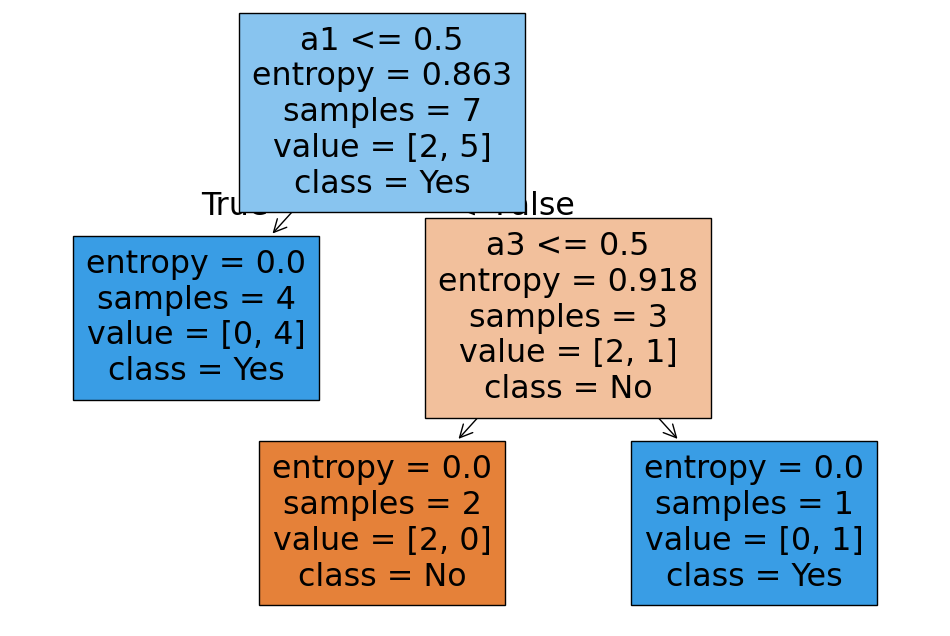

In [1]:
# -*- coding: utf-8 -*-
"""Decision_Tree.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1RXDK8CR1doVCMHgkaXpJsNLAvzOIaXdd
"""

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Create the dataset
data = {
    'a1': [True, True, False, False, False, True, True, True, False, False],
    'a2': ['Hot', 'Hot', 'Hot', 'Cool', 'Cool', 'Cool', 'Hot', 'Hot', 'Cool', 'Cool'],
    'a3': ['High', 'High', 'High', 'Normal', 'Normal', 'High', 'High', 'Normal', 'Normal', 'High'],
    'Classification': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes']
}

data

# Convert to DataFrame
df = pd.DataFrame(data)

# Convert categorical data to numerical data
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Split the dataset into features and target
X = df.drop('Classification', axis=1)
y = df['Classification']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Decision Tree Classifier with entropy as the criterion
clf = DecisionTreeClassifier(criterion='entropy')

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

# Optionally, visualize the decision tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=['No', 'Yes'])
plt.show()



Iris Dataset Decision Tree Accuracy: 1.0


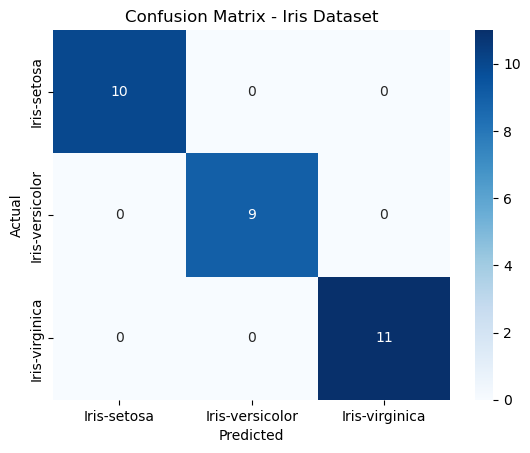

Drug Dataset Decision Tree Accuracy: 1.0


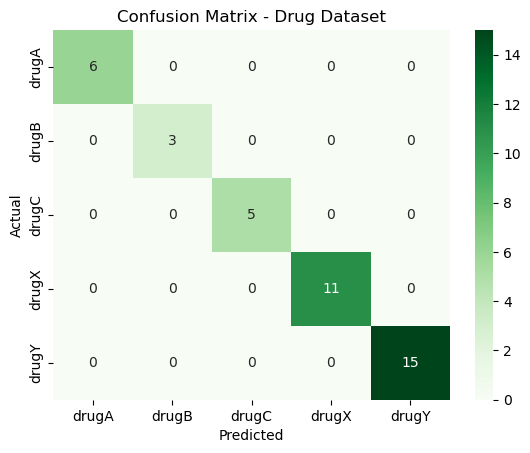

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# 1. IRIS Dataset
# -----------------------------
iris = pd.read_csv(r"C:\Users\BMSCECSE-SH\Downloads\iris (1).csv")

X_iris = iris.drop('species', axis=1)
y_iris = iris['species']

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

dt_iris = DecisionTreeClassifier(random_state=42)
dt_iris.fit(X_train, y_train)

y_pred = dt_iris.predict(X_test)

print("Iris Dataset Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

cm_iris = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Blues',
            xticklabels=dt_iris.classes_,
            yticklabels=dt_iris.classes_)
plt.title("Confusion Matrix - Iris Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 2. Drug Dataset
# -----------------------------
drug = pd.read_csv(r"C:\Users\BMSCECSE-SH\Downloads\drug.csv")

# Separate target before encoding
y_drug = drug['Drug']
X_drug = drug.drop('Drug', axis=1)

# Encode categorical features only (not the target)
X_drug = pd.get_dummies(X_drug, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_drug, y_drug, test_size=0.2, random_state=42)

# Build Decision Tree model
dt_drug = DecisionTreeClassifier(random_state=42)
dt_drug.fit(X_train, y_train)

y_pred = dt_drug.predict(X_test)

print("Drug Dataset Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

cm_drug = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_drug, annot=True, fmt='d', cmap='Greens',
            xticklabels=dt_drug.classes_,
            yticklabels=dt_drug.classes_)
plt.title("Confusion Matrix - Drug Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# -----------------------------
# Step 1: Load dataset
# -----------------------------
data = pd.read_csv(r"C:\Users\BMSCECSE-SH\Downloads\petrol_consumption.csv")

print(data.head())
print(data.info())

# -----------------------------
# Step 2: Features and Target
# -----------------------------
# Assuming 'Petrol_Consumption' is the target column
X = data.drop('Petrol_Consumption', axis=1)
y = data['Petrol_Consumption']

# -----------------------------
# Step 3: Train-Test Split (80/20)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Step 4: Build Regression Tree
# -----------------------------
reg_tree = DecisionTreeRegressor(random_state=42)
reg_tree.fit(X_train, y_train)

# -----------------------------
# Step 5: Predictions
# -----------------------------
y_pred = reg_tree.predict(X_test)

# -----------------------------
# Step 6: Evaluation Metrics
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

   Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)  \
0         9.0            3571            1976                         0.525   
1         9.0            4092            1250                         0.572   
2         9.0            3865            1586                         0.580   
3         7.5            4870            2351                         0.529   
4         8.0            4399             431                         0.544   

   Petrol_Consumption  
0                 541  
1                 524  
2                 561  
3                 414  
4                 410  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Petrol_tax                    48 non-null     float64
 1   Average_income                48 non-null     int64  
 2   Paved_Highways                48 non-n